# Prediction — CNN-ViT-BiLSTM Deepfake Detector

This notebook runs inference with the trained `CNN_ViT_BiLSTM` model on new videos.

**Inputs accepted:**
- A single video folder (contains frame images)
- A directory of video folders
- A dataset directory with `fake/` and `real/` subfolders (for labelled evaluation)

## Part 0: Imports

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    roc_curve
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

c:\Users\fatah.rahimi\Desktop\Models\my_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3060


## Part 1: Configuration

In [2]:
# ─────────────────────────────────────────────────────────
# Paths
# ─────────────────────────────────────────────────────────

# Path to the saved model weights (.pth)
MODEL_PATH = "video_model.pth"

# Choose ONE of the three input modes below:

# MODE A — labelled dataset root with fake/ and real/ subfolders
# (reproduces test-set evaluation from training notebook)
INPUT_MODE  = "dataset"          # "dataset" | "folder" | "single"
INPUT_PATH  = "../../dataset/test"

# MODE B — a directory of unlabelled video folders
# INPUT_MODE = "folder"
# INPUT_PATH = "path/to/videos"

# MODE C — a single video folder (frames inside)
# INPUT_MODE = "single"
# INPUT_PATH = "path/to/one_video"

# ─────────────────────────────────────────────────────────
# Inference hyper-parameters
# ─────────────────────────────────────────────────────────
NUM_FRAMES  = 16          # must match training
BATCH_SIZE  = 8
THRESHOLD   = 0.5         # decision boundary (real if prob >= threshold)

# ─────────────────────────────────────────────────────────
# Model hyper-parameters (must match training)
# ─────────────────────────────────────────────────────────
CNN_MODEL   = 'efficientnet_b0'
VIT_MODEL   = 'deit_tiny_patch16_224'
PROJ_DIM    = 128
LSTM_HIDDEN = 128
LSTM_LAYERS = 1
DROPOUT     = 0.4194

SEED = 42

## Part 2: Reproducibility & Device

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Part 3: Model Definition

In [4]:
class CNN_ViT_BiLSTM(nn.Module):
    """
    Hybrid CNN + ViT backbone with BiLSTM temporal aggregation.
    Binary classification: 0 = fake, 1 = real.
    """

    def __init__(
        self,
        cnn_model='efficientnet_b0',
        vit_model='deit_tiny_patch16_224',
        proj_dim=128,
        lstm_hidden=128,
        lstm_layers=1,
        dropout=0.4194,
        freeze_cnn=False,   # inference: no need to freeze
        freeze_vit=False
    ):
        super().__init__()

        # ── CNN Backbone ───────────────────────────────────
        self.cnn = timm.create_model(cnn_model, pretrained=False)
        self.cnn.reset_classifier(0)

        # ── ViT Backbone ───────────────────────────────────
        self.vit = timm.create_model(vit_model, pretrained=False)
        self.vit.reset_classifier(0)

        # ── Feature dimension inference ────────────────────
        with torch.no_grad():
            dummy = torch.randn(1, 3, 224, 224)
            cnn_feature_dim = self.cnn(dummy).shape[1]
            vit_feature_dim = self.vit(dummy).shape[1]

        # ── Projection layers ──────────────────────────────
        self.cnn_proj = nn.Sequential(
            nn.Linear(cnn_feature_dim, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.vit_proj = nn.Sequential(
            nn.Linear(vit_feature_dim, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ── Fusion ─────────────────────────────────────────
        self.fusion_norm = nn.LayerNorm(proj_dim * 2)

        # ── Temporal Modelling ─────────────────────────────
        self.lstm = nn.LSTM(
            input_size=proj_dim * 2,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.0 if lstm_layers == 1 else dropout
        )

        # ── Classification Head ────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)

        cnn_feat = self.cnn_proj(self.cnn(x))
        vit_feat = self.vit_proj(self.vit(x))

        fused = self.fusion_norm(torch.cat([cnn_feat, vit_feat], dim=1))
        seq_feat = fused.view(B, T, -1)

        lstm_out, _ = self.lstm(seq_feat)
        temporal_feat = lstm_out.mean(dim=1)

        return self.classifier(temporal_feat)

## Part 4: Load Trained Weights

In [5]:
model = CNN_ViT_BiLSTM(
    cnn_model=CNN_MODEL,
    vit_model=VIT_MODEL,
    proj_dim=PROJ_DIM,
    lstm_hidden=LSTM_HIDDEN,
    lstm_layers=LSTM_LAYERS,
    dropout=DROPOUT
).to(device)

assert os.path.exists(MODEL_PATH), f"Model file not found: {MODEL_PATH}"
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print(f"Model loaded from: {MODEL_PATH}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Model loaded from: video_model.pth
Total parameters: 10,149,437


C:\Users\fatah.rahimi\AppData\Local\Temp\ipykernel_19996\4134696034.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_loc

## Part 5: Preprocessing & Dataset

In [6]:
# ── Inference transform (same as val_test_transform in training) ──
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class PredictionDataset(Dataset):
    """
    Flexible dataset for inference.

    Supports three input structures:
      - dataset : root/fake/<video_dir>/frames  +  root/real/<video_dir>/frames
      - folder  : root/<video_dir>/frames  (no labels)
      - single  : root/frames              (no labels)
    """

    IMG_EXTS = (".jpg", ".jpeg", ".png")

    def __init__(self, root, mode="dataset", transform=None, num_frames=16):
        self.transform  = transform
        self.num_frames = num_frames
        self.samples    = []   # list of (frame_files, label_or_None, video_name)

        if mode == "dataset":
            for class_name, label in [("fake", 0), ("real", 1)]:
                class_dir = os.path.join(root, class_name)
                if not os.path.isdir(class_dir):
                    continue
                for video_name in sorted(os.listdir(class_dir)):
                    video_dir = os.path.join(class_dir, video_name)
                    if not os.path.isdir(video_dir):
                        continue
                    frames = self._collect_frames(video_dir)
                    if frames:
                        self.samples.append((frames, label, f"{class_name}/{video_name}"))

        elif mode == "folder":
            for video_name in sorted(os.listdir(root)):
                video_dir = os.path.join(root, video_name)
                if not os.path.isdir(video_dir):
                    continue
                frames = self._collect_frames(video_dir)
                if frames:
                    self.samples.append((frames, None, video_name))

        elif mode == "single":
            frames = self._collect_frames(root)
            if frames:
                self.samples.append((frames, None, os.path.basename(root)))

        else:
            raise ValueError(f"Unknown mode: {mode}")

        print(f"Found {len(self.samples)} video(s).")

    def _collect_frames(self, video_dir):
        return sorted([
            os.path.join(video_dir, f)
            for f in os.listdir(video_dir)
            if f.lower().endswith(self.IMG_EXTS)
        ])

    def _sample_indices(self, n_frames):
        return np.linspace(0, n_frames - 1, self.num_frames, dtype=int).tolist()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_files, label, video_name = self.samples[idx]
        indices = self._sample_indices(len(frame_files))

        frames = []
        for i in indices:
            img = Image.open(frame_files[i]).convert("RGB")
            if self.transform:
                img = self.transform(img)
            frames.append(img)

        frames_tensor = torch.stack(frames, dim=0)  # (T, C, H, W)

        if label is not None:
            return frames_tensor, torch.tensor(label, dtype=torch.float32), video_name
        else:
            return frames_tensor, video_name

## Part 6: Build DataLoader

In [7]:
dataset = PredictionDataset(
    root=INPUT_PATH,
    mode=INPUT_MODE,
    transform=inference_transform,
    num_frames=NUM_FRAMES
)

has_labels = (INPUT_MODE == "dataset")

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"Input mode : {INPUT_MODE}")
print(f"Has labels : {has_labels}")
print(f"Videos     : {len(dataset)}")

Found 111 video(s).
Input mode : dataset
Has labels : True
Videos     : 111


## Part 7: Run Inference

In [8]:
all_video_names = []
all_probs       = []
all_preds       = []
all_labels      = []   # empty when has_labels=False

model.eval()

with torch.no_grad():
    for batch in tqdm(loader, desc="Predicting"):

        if has_labels:
            videos, labels, video_names = batch
            all_labels.extend(labels.numpy().tolist())
        else:
            videos, video_names = batch

        videos  = videos.to(device)
        outputs = model(videos)
        probs   = torch.sigmoid(outputs).squeeze(1).cpu().numpy()
        preds   = (probs >= THRESHOLD).astype(int)

        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_video_names.extend(list(video_names))

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)

print("\nInference complete.")
print(f"  Predicted REAL : {all_preds.sum()}")
print(f"  Predicted FAKE : {(all_preds == 0).sum()}")

Predicting: 100%|██████████| 14/14 [00:08<00:00,  1.65it/s]


Inference complete.
  Predicted REAL : 50
  Predicted FAKE : 61


## Part 8: Results Table

In [9]:
label_map = {0: "fake", 1: "real"}

results = pd.DataFrame({
    "video"      : all_video_names,
    "prob_real"  : np.round(all_probs, 4),
    "prediction" : [label_map[p] for p in all_preds],
})

if has_labels:
    all_labels = np.array(all_labels)
    results["ground_truth"] = [label_map[int(l)] for l in all_labels]
    results["correct"]      = (all_preds == all_labels.astype(int))

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_colwidth", 60)
display(results)

,video,prob_real,prediction,ground_truth,correct
0,fake/01_02__outside_talking_still_laughing__YVGY8LOK,0.0002,fake,fake,True
1,fake/01_03__hugging_happy__ISF9SP4G,0.0002,fake,fake,True
2,fake/01_03__kitchen_pan__JZUXXFRB,0.0004,fake,fake,True
3,fake/01_03__meeting_serious__JZUXXFRB,0.0004,fake,fake,True
4,fake/01_03__outside_talking_pan_laughing__ISF9SP4G,0.0002,fake,fake,True
...,...,...,...,...,...
106,real/27__kitchen_pan,1.0000,real,real,True
107,real/27__meeting_serious,0.0019,fake,real,False
108,real/27__talking_against_wall,0.9999,real,real,True
109,real/28__outside_talking_still_laughing,1.0000,real,real,True


## Part 9: Evaluation Metrics  *(labelled dataset only)*

In [10]:
if not has_labels:
    print("No ground-truth labels — skipping metrics.")
else:
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)

    print(f"Accuracy  : {acc:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print()
    print(classification_report(
        all_labels.astype(int),
        all_preds,
        target_names=["fake", "real"]
    ))

Accuracy  : 0.9550
F1-score  : 0.9524
ROC-AUC   : 0.9854

              precision    recall  f1-score   support

        fake       0.92      1.00      0.96        56
        real       1.00      0.91      0.95        55

    accuracy                           0.95       111
   macro avg       0.96      0.95      0.95       111
weighted avg       0.96      0.95      0.95       111



## Part 10: Visualisations  *(labelled dataset only)*

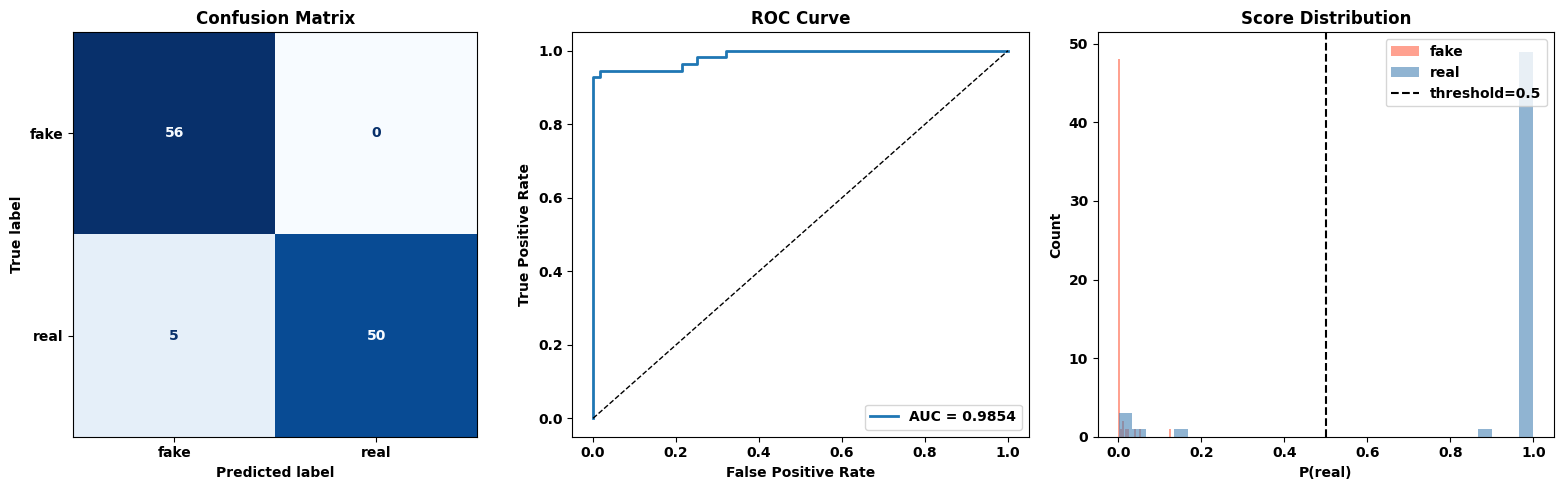

Plots saved to prediction_plots.png


In [11]:
plt.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

if not has_labels:
    print("No ground-truth labels — skipping plots.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ── Confusion Matrix ───────────────────────────────────
    cm = confusion_matrix(all_labels.astype(int), all_preds)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["fake", "real"]
    ).plot(cmap="Blues", colorbar=False, ax=axes[0])
    axes[0].set_title("Confusion Matrix")

    # ── ROC Curve ─────────────────────────────────────────
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    axes[1].plot(fpr, tpr, label=f"AUC = {auc:.4f}", linewidth=2)
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()

    # ── Score Distribution ────────────────────────────────
    fake_probs = all_probs[all_labels == 0]
    real_probs = all_probs[all_labels == 1]
    axes[2].hist(fake_probs, bins=30, alpha=0.6, label="fake", color="tomato")
    axes[2].hist(real_probs, bins=30, alpha=0.6, label="real", color="steelblue")
    axes[2].axvline(THRESHOLD, color="black", linestyle="--", linewidth=1.5, label=f"threshold={THRESHOLD}")
    axes[2].set_xlabel("P(real)")
    axes[2].set_ylabel("Count")
    axes[2].set_title("Score Distribution")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig("prediction_plots.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plots saved to prediction_plots.png")

## Part 11: Probability Distribution  *(all modes)*

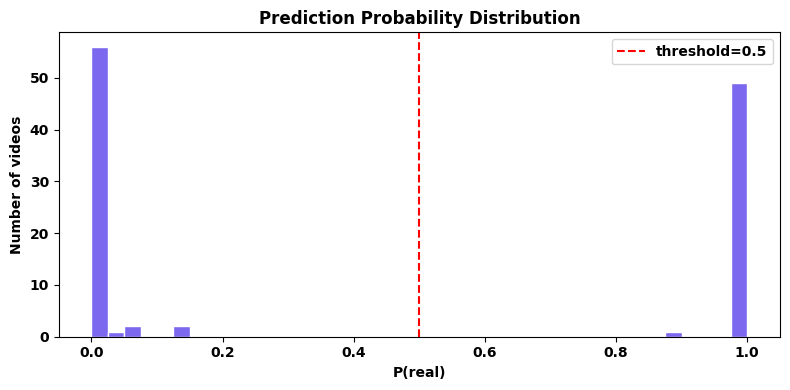

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(all_probs, bins=40, color="mediumslateblue", edgecolor="white")
plt.axvline(THRESHOLD, color="red", linestyle="--", linewidth=1.5, label=f"threshold={THRESHOLD}")
plt.xlabel("P(real)")
plt.ylabel("Number of videos")
plt.title("Prediction Probability Distribution")
plt.legend()
plt.tight_layout()
plt.show()

## Part 12: Save Predictions to CSV

In [13]:
csv_path = "predictions.csv"
results.to_csv(csv_path, index=False)
print(f"Predictions saved to: {csv_path}")
display(results.head(10))

Predictions saved to: predictions.csv


,video,prob_real,prediction,ground_truth,correct
0,fake/01_02__outside_talking_still_laughing__YVGY8LOK,0.0002,fake,fake,True
1,fake/01_03__hugging_happy__ISF9SP4G,0.0002,fake,fake,True
2,fake/01_03__kitchen_pan__JZUXXFRB,0.0004,fake,fake,True
3,fake/01_03__meeting_serious__JZUXXFRB,0.0004,fake,fake,True
4,fake/01_03__outside_talking_pan_laughing__ISF9SP4G,0.0002,fake,fake,True
5,fake/01_03__talking_angry_couch__ISF9SP4G,0.0002,fake,fake,True
6,fake/01_04__walk_down_hall_angry__GBC7ZGDP,0.0002,fake,fake,True
7,fake/01_09__secret_conversation__SJZRV69J,0.0022,fake,fake,True
8,fake/01_09__walk_down_hall_angry__P70H1JB0,0.0002,fake,fake,True
9,fake/01_11__exit_phone_room__9229VVZ3,0.0002,fake,fake,True


## Part 13: Predict a Single Custom Video Folder

In [22]:
def predict_video(video_folder, model, transform, num_frames=16, threshold=0.5, device="cpu"):
    """
    Predict whether a single video folder is real or fake.

    Args:
        video_folder (str): Path to folder containing frame images.
        model       : Loaded CNN_ViT_BiLSTM model in eval mode.
        transform   : torchvision transform for preprocessing.
        num_frames  (int): Number of frames to sample.
        threshold   (float): Decision boundary.
        device      : torch device.

    Returns:
        dict: {"prediction": str, "prob_real": float, "prob_fake": float}
    """
    IMG_EXTS = (".jpg", ".jpeg", ".png")

    frame_files = sorted([
        os.path.join(video_folder, f)
        for f in os.listdir(video_folder)
        if f.lower().endswith(IMG_EXTS)
    ])

    if not frame_files:
        raise FileNotFoundError(f"No image frames found in: {video_folder}")

    indices = np.linspace(0, len(frame_files) - 1, num_frames, dtype=int)
    frames  = [transform(Image.open(frame_files[i]).convert("RGB")) for i in indices]
    tensor  = torch.stack(frames, dim=0).unsqueeze(0).to(device)  # (1, T, C, H, W)

    model.eval()
    with torch.no_grad():
        prob_real = torch.sigmoid(model(tensor)).item()

    label = "real" if prob_real >= threshold else "fake"

    return {
        "prediction" : label,
        "prob_real"  : round(prob_real, 4),
        "prob_fake"  : round(1 - prob_real, 4)
    }


# ── Example usage ─────────────────────────────────────────
result = predict_video(
    video_folder = r"..\..\processed_ffpp\test\fake\02_27__hugging_happy__GVFLSZD5",
    model        = model,
    transform    = inference_transform,
    num_frames   = NUM_FRAMES,
    threshold    = THRESHOLD,
    device       = device
)
print(result)

print("predict_video() is ready. Uncomment the example above to use it.")

{'prediction': 'fake', 'prob_real': 0.0002, 'prob_fake': 0.9998}
predict_video() is ready. Uncomment the example above to use it.
